# Household Energy Forecasting with Recurrent Neural Networks

This case study investigates short-term household appliance-energy forecasting with **PyTorch recurrent neural networks** using the UCI *Appliances Energy Prediction* dataset.

The project focuses on recurrent modeling and time-series methodology rather than benchmark optimization. It compares:

- persistence and daily-seasonal baselines;
- vanilla RNN, LSTM, and GRU cells;
- different historical context lengths;
- one- versus two-layer recurrent models;
- a small validation-only hyperparameter search;
- one-step forecasting on a locked chronological test period;
- direct multi-horizon forecasting up to 60 minutes ahead.

The primary model-selection metric is **validation RMSE**. MAE is reported as a secondary metric.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from dataclasses import dataclass
from typing import Dict, List
from itertools import product
import copy
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0+cu130
Device: cuda


## 2. Configuration

In [2]:
FAST_DEV_RUN = False

BATCH_SIZE = 32
BASE_SEQUENCE_LENGTH = 36       # 6 hours
SEQUENCE_LENGTHS = [6, 36, 144] # 1 h, 6 h, 24 h
HORIZON = 1

ARCH_EPOCHS = 30 if not FAST_DEV_RUN else 2
CONTEXT_EPOCHS = 30 if not FAST_DEV_RUN else 2
DEPTH_EPOCHS = 30 if not FAST_DEV_RUN else 2
SEARCH_EPOCHS = 25 if not FAST_DEV_RUN else 2
SEARCH_TRIALS = 8 if not FAST_DEV_RUN else 2
MULTI_EPOCHS = 30 if not FAST_DEV_RUN else 2

SEARCH_SEED = 42

## 3. Download and load the dataset

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/374/"
    "appliances%2Benergy%2Bprediction.zip"
)

zip_path = DATA_DIR / "appliances_energy_prediction.zip"
csv_path = DATA_DIR / "energydata_complete.csv"

if not csv_path.exists():
    if not zip_path.exists():
        print("Downloading dataset from UCI...")
        urlretrieve(UCI_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as zf:
        members = [
            name for name in zf.namelist()
            if name.lower().endswith("energydata_complete.csv")
        ]

        if not members:
            raise FileNotFoundError(
                "energydata_complete.csv was not found inside the UCI archive."
            )

        member = members[0]
        zf.extract(member, DATA_DIR)
        extracted = DATA_DIR / member

        if extracted != csv_path:
            extracted.replace(csv_path)

df = pd.read_csv(csv_path, parse_dates=["date"])

print("Shape:", df.shape)
display(df.head())

Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## 4. Temporal data audit

In [4]:
print("Date range:", df["date"].min(), "->", df["date"].max())
print("Sorted by time:", df["date"].is_monotonic_increasing)
print("Missing values:", int(df.isna().sum().sum()))
print("Exact duplicates:", int(df.duplicated().sum()))

step_minutes = (
    df["date"]
    .diff()
    .dropna()
    .dt.total_seconds()
    .div(60)
)

print("Sampling intervals (minutes):")
print(step_minutes.value_counts().sort_index())

print("\nTarget summary:")
print(df["Appliances"].describe())

print("\nRandom-variable sanity check:")
print(
    df[["rv1", "rv2", "Appliances"]]
    .corr()["Appliances"]
    .drop("Appliances")
)

Date range: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
Sorted by time: True
Missing values: 0
Exact duplicates: 0
Sampling intervals (minutes):
date
10.0    19734
Name: count, dtype: int64

Target summary:
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

Random-variable sanity check:
rv1   -0.011145
rv2   -0.011145
Name: Appliances, dtype: float64


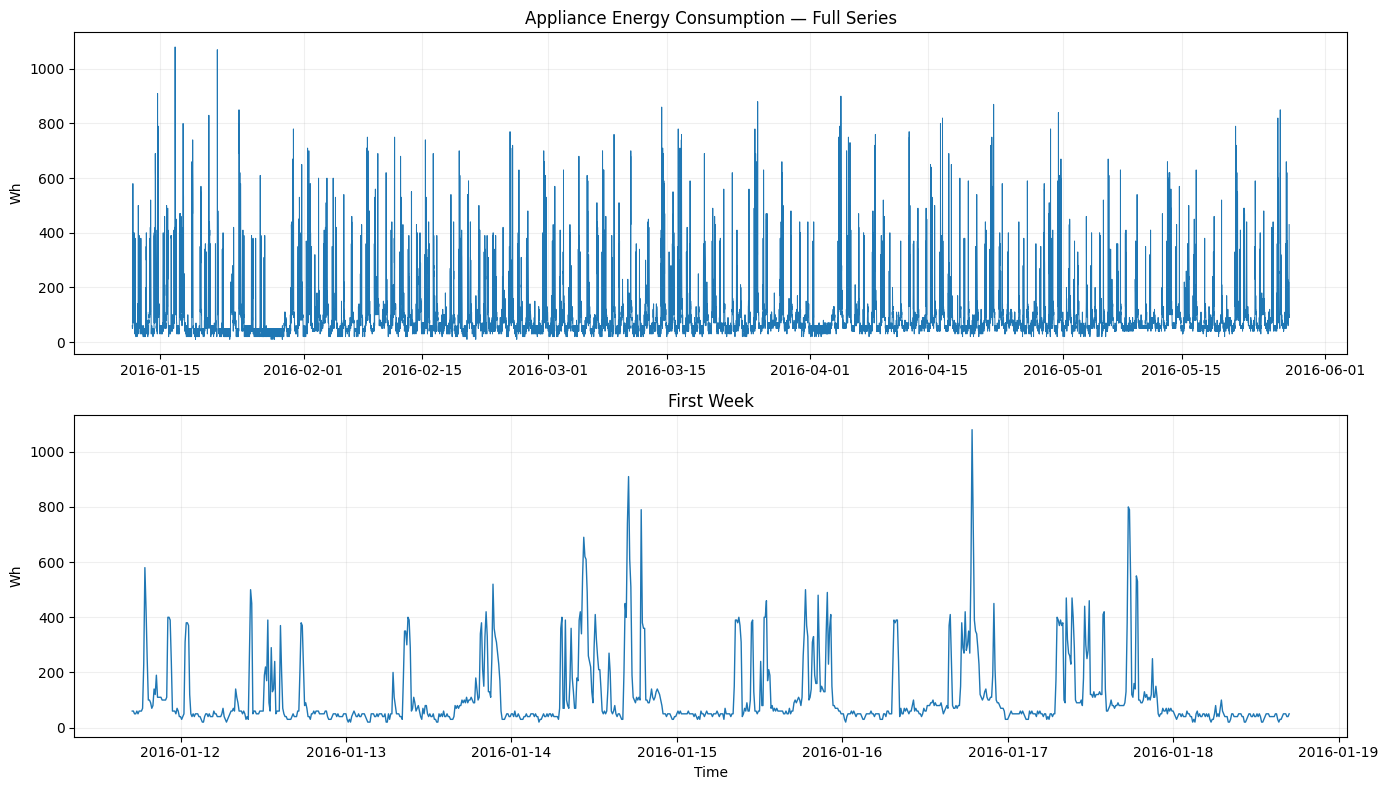

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["date"], df["Appliances"], linewidth=0.7)
axes[0].set_title("Appliance Energy Consumption — Full Series")
axes[0].set_ylabel("Wh")
axes[0].grid(alpha=0.2)

one_week = 7 * 24 * 6
axes[1].plot(
    df["date"].iloc[:one_week],
    df["Appliances"].iloc[:one_week],
    linewidth=1.0,
)
axes[1].set_title("First Week")
axes[1].set_ylabel("Wh")
axes[1].set_xlabel("Time")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Temporal audit observations

The dataset is unusually clean for a real time series: there are **19,735 observations**, no missing values, no exact duplicates, and every timestamp is separated by exactly **10 minutes**. The observed period runs from January 11 to May 27, 2016, giving roughly 137 days of continuous household measurements.

`Appliances` is strongly right-skewed. The median consumption is only **60 Wh**, while the mean is approximately **97.7 Wh** and the maximum reaches **1,080 Wh**. This difference is important because most observations correspond to relatively low consumption, but a small number of large spikes can dominate squared-error metrics.

The complete series also looks intermittent rather than smoothly periodic: long low-consumption periods are interrupted by short bursts of much higher demand. Daily activity patterns are visible, but the magnitude and duration of the peaks vary considerably.

Finally, `rv1` and `rv2` have correlations of approximately **-0.01** with the target, which is consistent with their intended role as random variables. They are therefore removed before modeling.

## 5. Time features

The timestamp is represented cyclically rather than as a raw numeric value. The time-of-day encoding uses minutes since midnight:

\begin{equation}
\theta_{day}=2\pi\frac{\text{minutes since midnight}}{1440}
\end{equation}

and day of week uses period 7. The two intentionally random variables (`rv1`, `rv2`) are removed from the model inputs.

In [6]:
timestamps = df["date"].copy()

minutes_of_day = (
    df["date"].dt.hour * 60
    + df["date"].dt.minute
)

day_of_week = df["date"].dt.dayofweek

model_df = df.drop(columns=["date", "rv1", "rv2"]).copy()

model_df["tod_sin"] = np.sin(
    2 * np.pi * minutes_of_day / 1440
)
model_df["tod_cos"] = np.cos(
    2 * np.pi * minutes_of_day / 1440
)
model_df["dow_sin"] = np.sin(
    2 * np.pi * day_of_week / 7
)
model_df["dow_cos"] = np.cos(
    2 * np.pi * day_of_week / 7
)

print("Modeling shape:", model_df.shape)
print("Target column:", "Appliances")
print("Number of input features per timestep:", model_df.shape[1])

Modeling shape: (19735, 30)
Target column: Appliances
Number of input features per timestep: 30


## 6. Chronological train / validation / test split

In [7]:
n = len(model_df)
train_end = int(0.70 * n)
valid_end = int(0.85 * n)

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df = model_df.iloc[valid_end:].copy()

train_dates = timestamps.iloc[:train_end].reset_index(drop=True)
valid_dates = timestamps.iloc[train_end:valid_end].reset_index(drop=True)
test_dates = timestamps.iloc[valid_end:].reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(valid_df), len(test_df)],
    "start": [
        timestamps.iloc[0],
        timestamps.iloc[train_end],
        timestamps.iloc[valid_end],
    ],
    "end": [
        timestamps.iloc[train_end - 1],
        timestamps.iloc[valid_end - 1],
        timestamps.iloc[-1],
    ],
})

display(split_summary)

,split,rows,start,end
0,train,13814,2016-01-11 17:00:00,2016-04-16 15:10:00
1,validation,2960,2016-04-16 15:20:00,2016-05-07 04:30:00
2,test,2961,2016-05-07 04:40:00,2016-05-27 18:00:00


## 7. Train-only scaling

In [8]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df).astype("float32")
valid_scaled = scaler.transform(valid_df).astype("float32")
test_scaled = scaler.transform(test_df).astype("float32")

target_col_index = train_df.columns.get_loc("Appliances")
scaling_mean = scaler.mean_[target_col_index]
scaling_std = scaler.scale_[target_col_index]

n_features = train_scaled.shape[1]

print("Input features:", n_features)
print("Target index:", target_col_index)
print("Target scaling mean:", scaling_mean)
print("Target scaling std:", scaling_std)

Input features: 30
Target index: 0
Target scaling mean: 98.7751556392066
Target scaling std: 106.853424078282


## 8. Sliding-window dataset with split-boundary context

In [9]:
class SequenceDataset(Dataset):
    def __init__(
        self,
        data,
        sequence_length,
        horizon=1,
        tgt_col_idx=0,
    ):
        self.data = torch.as_tensor(
            data,
            dtype=torch.float32,
        )
        self.sequence_length = sequence_length
        self.horizon = horizon
        self.tgt_col_idx = tgt_col_idx

    def __len__(self):
        return (
            len(self.data)
            - self.sequence_length
            - self.horizon
            + 1
        )

    def __getitem__(self, index):
        input_end = index + self.sequence_length
        target_end = input_end + self.horizon

        X = self.data[index:input_end]
        y = self.data[
            input_end:target_end,
            self.tgt_col_idx,
        ]

        return X, y


def with_history_context(previous_scaled, current_scaled, sequence_length):
    if len(previous_scaled) < sequence_length:
        raise ValueError("Not enough historical context for requested sequence length.")

    return np.concatenate(
        [previous_scaled[-sequence_length:], current_scaled],
        axis=0,
    )


def make_datasets(sequence_length, horizon=1):
    train_dataset = SequenceDataset(
        train_scaled,
        sequence_length=sequence_length,
        horizon=horizon,
        tgt_col_idx=target_col_index,
    )

    valid_with_context = with_history_context(
        train_scaled,
        valid_scaled,
        sequence_length,
    )

    valid_dataset = SequenceDataset(
        valid_with_context,
        sequence_length=sequence_length,
        horizon=horizon,
        tgt_col_idx=target_col_index,
    )

    return train_dataset, valid_dataset


def make_loader(dataset, *, shuffle, batch_size=BATCH_SIZE, seed=RANDOM_STATE):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
    )

In [10]:
train_dataset_36, valid_dataset_36 = make_datasets(
    BASE_SEQUENCE_LENGTH,
    HORIZON,
)

train_loader_36 = make_loader(train_dataset_36, shuffle=True)
valid_loader_36 = make_loader(valid_dataset_36, shuffle=False)

X_batch, y_batch = next(iter(train_loader_36))

print("X batch shape:", tuple(X_batch.shape))
print("y batch shape:", tuple(y_batch.shape))
print("Validation targets evaluated:", len(valid_dataset_36))
print("Validation rows available:", len(valid_df))

X batch shape: (32, 36, 30)
y batch shape: (32, 1)
Validation targets evaluated: 2960
Validation rows available: 2960


## 9. Baselines aligned to the forecast period

In [11]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true

    return {
        "mae": float(np.mean(np.abs(residual))),
        "rmse": float(np.sqrt(np.mean(residual ** 2))),
    }


def lag_baseline(target_series, start, end, lag):
    actual = target_series[start:end]
    pred = target_series[start - lag:end - lag]
    return regression_metrics(actual, pred)

all_target_real = model_df["Appliances"].to_numpy(dtype=float)

validation_baselines = []
for name, lag in [("Persistence (lag 1)", 1), ("Daily seasonal (lag 144)", 144)]:
    metrics = lag_baseline(
        all_target_real,
        start=train_end,
        end=valid_end,
        lag=lag,
    )
    validation_baselines.append({"model": name, **metrics})

validation_baselines_df = pd.DataFrame(validation_baselines)
display(validation_baselines_df)

persistence_valid_mae = float(
    validation_baselines_df.loc[
        validation_baselines_df["model"] == "Persistence (lag 1)",
        "mae",
    ].iloc[0]
)
persistence_valid_rmse = float(
    validation_baselines_df.loc[
        validation_baselines_df["model"] == "Persistence (lag 1)",
        "rmse",
    ].iloc[0]
)

,model,mae,rmse
0,Persistence (lag 1),26.162162,66.429703
1,Daily seasonal (lag 144),53.320946,115.383760


### Baseline analysis

The one-step persistence baseline is much stronger than the daily seasonal baseline:

| Baseline | MAE (Wh) | RMSE (Wh) |
|---|---:|---:|
| Persistence — lag 1 | **26.16** | **66.43** |
| Daily seasonal — lag 144 | 53.32 | 115.38 |

This suggests that appliance consumption has much stronger **short-term continuity** than exact day-to-day repetition. For a 10-minute forecast, the latest observed consumption is already a difficult baseline to beat.

The large difference between MAE and RMSE is also informative. Most individual errors are moderate, but occasional consumption spikes create much larger residuals and receive disproportionate weight under RMSE.

For that reason, persistence is not treated as a trivial benchmark. A recurrent model should ideally improve both metrics, but a meaningful RMSE reduction can still indicate that it handles large errors better even if its MAE remains similar.

## 10. Training utilities

In [12]:
def train_like_agg_fn(metrics_list, batch_lengths):
    metrics_vector = torch.stack(metrics_list)
    lengths_vector = torch.stack(batch_lengths)
    data_length = torch.sum(lengths_vector)
    return torch.sum(metrics_vector * lengths_vector) / data_length


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    *,
    max_grad_norm=None,
):
    model.train()
    losses = []
    batch_lengths = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()

        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_grad_norm,
            )

        optimizer.step()

        losses.append(loss.detach())
        batch_lengths.append(
            torch.tensor(len(X_batch), device=device)
        )

    return train_like_agg_fn(losses, batch_lengths).item()


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    batch_lengths = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        losses.append(loss)
        batch_lengths.append(
            torch.tensor(len(X_batch), device=device)
        )

    return train_like_agg_fn(losses, batch_lengths).item()


@torch.no_grad()
def predict_scaled(model, loader, device):
    model.eval()
    predictions = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        predictions.append(model(X_batch).cpu())
        targets.append(y_batch.cpu())

    return (
        torch.cat(targets, dim=0),
        torch.cat(predictions, dim=0),
    )


@dataclass
class TrainResult:
    best_state: Dict
    train_loss_history: List[float]
    validation_loss_history: List[float]
    best_epoch: int
    best_validation_loss: float


def fit_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    device,
    n_epochs,
    *,
    max_grad_norm=1.0,
    verbose=True,
):
    train_history = []
    valid_history = []
    best_validation = float("inf")
    best_state = None
    best_epoch = None

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            max_grad_norm=max_grad_norm,
        )
        valid_loss = evaluate_loss(
            model,
            valid_loader,
            criterion,
            device,
        )

        train_history.append(train_loss)
        valid_history.append(valid_loss)

        if valid_loss < best_validation:
            best_validation = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if verbose:
            print(
                f"Epoch {epoch:02d}/{n_epochs} | "
                f"train MSE={train_loss:.4f} | "
                f"validation MSE={valid_loss:.4f}"
            )

    return TrainResult(
        best_state=best_state,
        train_loss_history=train_history,
        validation_loss_history=valid_history,
        best_epoch=best_epoch,
        best_validation_loss=best_validation,
    )


def inverse_target(values_scaled, mean=scaling_mean, std=scaling_std):
    values_scaled = np.asarray(values_scaled, dtype=float)
    return values_scaled * std + mean


def evaluate_real_units(
    model,
    loader,
    device,
    *,
    mean=scaling_mean,
    std=scaling_std,
):
    y_true_scaled, y_pred_scaled = predict_scaled(
        model,
        loader,
        device,
    )

    y_true = inverse_target(y_true_scaled.numpy(), mean, std)
    y_pred = inverse_target(y_pred_scaled.numpy(), mean, std)

    metrics = regression_metrics(y_true, y_pred)
    return metrics, y_true.squeeze(), y_pred.squeeze()


def count_parameters(model):
    return sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )


def plot_history(result, title):
    epochs = np.arange(1, len(result.train_loss_history) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, result.train_loss_history, label="Train")
    plt.plot(epochs, result.validation_loss_history, label="Validation")
    plt.axvline(
        result.best_epoch,
        linestyle="--",
        label=f"Best epoch ({result.best_epoch})",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Scaled MSE")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

## 11. Recurrent model definitions

In [13]:
class RNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, X):
        output, _ = self.rnn(X)
        return self.head(output[:, -1, :])


class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, X):
        _, (h_n, _) = self.lstm(X)
        return self.head(h_n[-1])


class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, X):
        _, h_n = self.gru(X)
        return self.head(h_n[-1])


MODEL_CLASSES = {
    "RNN": RNNRegressor,
    "LSTM": LSTMRegressor,
    "GRU": GRURegressor,
}

## 12. RNN vs LSTM vs GRU — 6-hour context

In [14]:
def train_candidate(
    model_name,
    sequence_length,
    *,
    hidden_size=64,
    num_layers=1,
    lr=1e-3,
    weight_decay=0.0,
    n_epochs=ARCH_EPOCHS,
    seed=RANDOM_STATE,
):
    train_dataset, valid_dataset = make_datasets(
        sequence_length,
        HORIZON,
    )

    train_loader = make_loader(
        train_dataset,
        shuffle=True,
        seed=seed,
    )
    valid_loader = make_loader(
        valid_dataset,
        shuffle=False,
    )

    torch.manual_seed(seed)
    model = MODEL_CLASSES[model_name](
        input_size=n_features,
        hidden_size=hidden_size,
        num_layers=num_layers,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    result = fit_model(
        model,
        train_loader,
        valid_loader,
        optimizer,
        criterion,
        device,
        n_epochs=n_epochs,
        max_grad_norm=1.0,
        verbose=False,
    )

    model.load_state_dict(result.best_state)
    metrics, _, _ = evaluate_real_units(
        model,
        valid_loader,
        device,
    )

    return model, result, metrics


architecture_rows = []
architecture_artifacts = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    model, result, metrics = train_candidate(
        model_name,
        BASE_SEQUENCE_LENGTH,
    )

    architecture_artifacts[model_name] = (model, result)
    architecture_rows.append({
        "model": model_name,
        "sequence_length": BASE_SEQUENCE_LENGTH,
        "parameters": count_parameters(model),
        "best_epoch": result.best_epoch,
        "validation_mae": metrics["mae"],
        "validation_rmse": metrics["rmse"],
    })

architecture_results = (
    pd.DataFrame(architecture_rows)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(architecture_results)

selected_cell = architecture_results.iloc[0]["model"]
print("Selected recurrent cell by validation RMSE:", selected_cell)

,model,sequence_length,parameters,best_epoch,validation_mae,validation_rmse
0,GRU,36,18497,7,25.984000,58.309119
1,RNN,36,6209,9,26.577262,58.620657
2,LSTM,36,24641,7,27.649612,58.954843


Selected recurrent cell by validation RMSE: GRU


### Recurrent architecture comparison

Using the same 6-hour context and training protocol, the three recurrent cells produce fairly close validation results:

| Model | Parameters | MAE (Wh) | RMSE (Wh) |
|---|---:|---:|---:|
| RNN | 6,209 | 26.58 | 58.62 |
| LSTM | 24,641 | 27.65 | 58.95 |
| GRU | 18,497 | **25.98** | **58.31** |

All three reduce RMSE substantially relative to persistence, which confirms that the recurrent models are learning temporal structure beyond the last observed value.

The **GRU provides the best validation RMSE and MAE among the recurrent architectures**, while using fewer parameters than the LSTM. The LSTM's additional memory mechanism does not provide a measurable advantage for this 6-hour context.

The differences between recurrent models are still relatively small, so this result should not be interpreted as evidence that GRUs are generally superior. For this dataset and forecasting setup, however, the GRU offers the best complexity-performance tradeoff and is therefore selected for the next experiments.

## 13. Historical context length

In [15]:
context_rows = []
context_artifacts = {}

for sequence_length in SEQUENCE_LENGTHS:
    model, result, metrics = train_candidate(
        selected_cell,
        sequence_length,
        n_epochs=CONTEXT_EPOCHS,
    )

    context_artifacts[sequence_length] = (model, result)
    context_rows.append({
        "model": selected_cell,
        "sequence_length": sequence_length,
        "hours_of_history": sequence_length / 6,
        "best_epoch": result.best_epoch,
        "validation_mae": metrics["mae"],
        "validation_rmse": metrics["rmse"],
    })

context_results = (
    pd.DataFrame(context_rows)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(context_results)

selected_sequence_length = int(
    context_results.iloc[0]["sequence_length"]
)
print("Selected sequence length:", selected_sequence_length)

,model,sequence_length,hours_of_history,best_epoch,validation_mae,validation_rmse
0,GRU,36,6.0,7,25.984000,58.309119
1,GRU,6,1.0,4,25.973339,58.410487
2,GRU,144,24.0,4,26.627915,58.590651


Selected sequence length: 36


### Historical-context analysis

Increasing the amount of history does not produce a monotonic improvement:

| History | Timesteps | MAE (Wh) | RMSE (Wh) |
|---|---:|---:|---:|
| 1 hour | 6 | **25.97** | 58.41 |
| 6 hours | 36 | 25.98 | **58.31** |
| 24 hours | 144 | 26.63 | 58.59 |

The 1-hour and 6-hour windows are almost indistinguishable in MAE, while the 6-hour context produces the best RMSE and is selected according to the predefined primary metric.

The 24-hour sequence does not improve performance despite containing a full daily cycle. This suggests that, for the one-step 10-minute forecast, recent appliance and environmental conditions contain most of the useful predictive information. Longer sequences may add redundant or weakly relevant history while also making recurrent optimization more difficult.

The differences are small, so the important conclusion is not that six hours is intrinsically optimal, but that **more temporal context is not automatically more useful**.

## 14. One vs. two recurrent layers

In [16]:
depth_rows = []
depth_artifacts = {}

for num_layers in [1, 2]:
    model, result, metrics = train_candidate(
        selected_cell,
        selected_sequence_length,
        num_layers=num_layers,
        n_epochs=DEPTH_EPOCHS,
    )

    depth_artifacts[num_layers] = (model, result)
    depth_rows.append({
        "model": selected_cell,
        "sequence_length": selected_sequence_length,
        "num_layers": num_layers,
        "parameters": count_parameters(model),
        "best_epoch": result.best_epoch,
        "validation_mae": metrics["mae"],
        "validation_rmse": metrics["rmse"],
    })

depth_results = (
    pd.DataFrame(depth_rows)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(depth_results)

selected_num_layers = int(depth_results.iloc[0]["num_layers"])
print("Selected recurrent depth:", selected_num_layers)

,model,sequence_length,num_layers,parameters,best_epoch,validation_mae,validation_rmse
0,GRU,36,2,43457,6,25.253338,58.136991
1,GRU,36,1,18497,7,25.984000,58.309119


Selected recurrent depth: 2


### Recurrent-depth analysis

Adding a second GRU layer improves both validation metrics:

| Layers | Parameters | MAE (Wh) | RMSE (Wh) |
|---|---:|---:|---:|
| 1 | 18,497 | 25.98 | 58.31 |
| 2 | 43,457 | **25.25** | **58.14** |

The RMSE improvement is modest, while the MAE reduction is more noticeable. At the same time, the parameter count more than doubles.

This indicates that additional recurrent depth provides some useful representation capacity, but the gain is not large enough to justify further depth without evidence. The two-layer GRU is retained for tuning because it improves the predefined validation metric, while deeper configurations are intentionally not explored.

## 15. Validation-only hyperparameter search

In [17]:
class TunedRecurrentRegressor(nn.Module):
    def __init__(
        self,
        cell_type,
        input_size,
        hidden_size=64,
        num_layers=1,
        dropout=0.1,
        output_size=1,
    ):
        super().__init__()

        recurrent_cls = {
            "RNN": nn.RNN,
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }[cell_type]

        self.cell_type = cell_type
        self.recurrent = recurrent_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        recurrent_output = self.recurrent(X)

        if self.cell_type == "LSTM":
            _, (h_n, _) = recurrent_output
        else:
            _, h_n = recurrent_output

        final_hidden = self.dropout(h_n[-1])
        return self.head(final_hidden)

In [18]:
search_space = list(product(
    [32, 64],
    [3e-4, 1e-3],
    [0.1, 0.2, 0.3],
    [1e-4, 1e-3],
))

rng = random.Random(SEARCH_SEED)
rng.shuffle(search_space)
trial_configs = search_space[:SEARCH_TRIALS]

search_train_dataset, search_valid_dataset = make_datasets(
    selected_sequence_length,
    HORIZON,
)

search_rows = []
best_search_loss = float("inf")
best_config = None
best_search_state = None
best_search_result = None

for trial, (hidden_size, lr, dropout, weight_decay) in enumerate(
    trial_configs,
    start=1,
):
    train_loader = make_loader(
        search_train_dataset,
        shuffle=True,
        seed=SEARCH_SEED,
    )
    valid_loader = make_loader(
        search_valid_dataset,
        shuffle=False,
    )

    torch.manual_seed(SEARCH_SEED)
    model = TunedRecurrentRegressor(
        cell_type=selected_cell,
        input_size=n_features,
        hidden_size=hidden_size,
        num_layers=selected_num_layers,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    result = fit_model(
        model,
        train_loader,
        valid_loader,
        optimizer,
        nn.MSELoss(),
        device,
        n_epochs=SEARCH_EPOCHS,
        max_grad_norm=1.0,
        verbose=False,
    )

    model.load_state_dict(result.best_state)
    metrics, _, _ = evaluate_real_units(model, valid_loader, device)

    row = {
        "trial": trial,
        "hidden_size": hidden_size,
        "lr": lr,
        "dropout": dropout,
        "weight_decay": weight_decay,
        "best_epoch": result.best_epoch,
        "validation_mae": metrics["mae"],
        "validation_rmse": metrics["rmse"],
        "validation_mse_scaled": result.best_validation_loss,
    }
    search_rows.append(row)

    if metrics["rmse"] < best_search_loss:
        best_search_loss = metrics["rmse"]
        best_config = row.copy()
        best_search_state = copy.deepcopy(result.best_state)
        best_search_result = result

search_results = (
    pd.DataFrame(search_rows)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(search_results)

print("Selected cell:", selected_cell)
print("Selected sequence length:", selected_sequence_length)
print("Selected recurrent layers:", selected_num_layers)
print("Best search configuration:")
print(best_config)

,trial,hidden_size,lr,dropout,weight_decay,best_epoch,validation_mae,validation_rmse,validation_mse_scaled
0,7,64,0.0003,0.3,0.0010,15,25.749441,57.911300,0.293731
1,8,32,0.0010,0.3,0.0010,9,24.814059,57.931499,0.293936
2,6,32,0.0010,0.3,0.0001,9,24.819999,57.933216,0.293953
3,5,64,0.0003,0.1,0.0010,15,26.431492,57.950101,0.294125
4,1,64,0.0003,0.2,0.0010,15,26.007396,57.957494,0.294200
5,2,32,0.0003,0.3,0.0010,22,24.861044,57.973790,0.294365
6,3,64,0.0010,0.1,0.0001,10,26.030385,58.010911,0.294742
7,4,64,0.0010,0.3,0.0010,7,25.646006,58.059247,0.295234


Selected cell: GRU
Selected sequence length: 36
Selected recurrent layers: 2
Best search configuration:
{'trial': 7, 'hidden_size': 64, 'lr': 0.0003, 'dropout': 0.3, 'weight_decay': 0.001, 'best_epoch': 15, 'validation_mae': 25.749440976617922, 'validation_rmse': 57.911300200899426, 'validation_mse_scaled': 0.2937309741973877}


Final selected validation metrics:
{'mae': 25.749440976617922, 'rmse': 57.911300200899426}


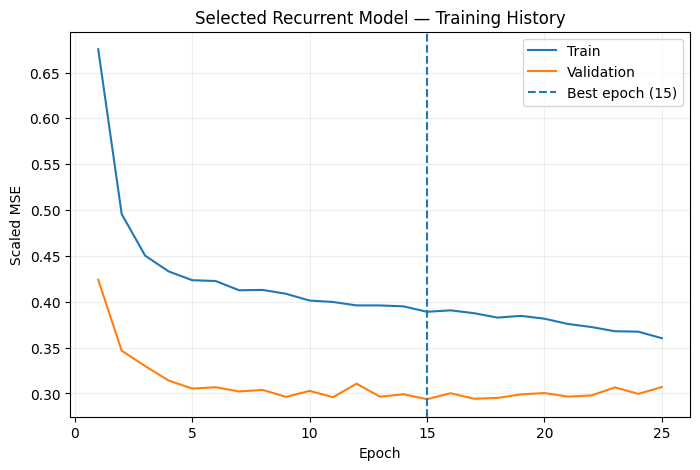

In [19]:
best_validation_model = TunedRecurrentRegressor(
    cell_type=selected_cell,
    input_size=n_features,
    hidden_size=int(best_config["hidden_size"]),
    num_layers=selected_num_layers,
    dropout=float(best_config["dropout"]),
).to(device)

best_validation_model.load_state_dict(best_search_state)

validation_loader_final = make_loader(
    search_valid_dataset,
    shuffle=False,
)

validation_metrics, validation_true, validation_pred = evaluate_real_units(
    best_validation_model,
    validation_loader_final,
    device,
)

print("Final selected validation metrics:")
print(validation_metrics)
plot_history(best_search_result, "Selected Recurrent Model — Training History")

### Hyperparameter-search analysis

The best configuration by **validation RMSE**, which was fixed as the primary selection metric before the search, is:

- GRU;
- 6-hour input window;
- 2 recurrent layers;
- hidden size = 64;
- learning rate = `3e-4`;
- dropout = `0.3`;
- weight decay = `1e-3`;
- best epoch = 15.

It reaches:

- **Validation MAE: 25.75 Wh**
- **Validation RMSE: 57.91 Wh**

Some trials achieve a slightly lower MAE, but they are not selected because the search criterion is RMSE. This distinction is important: the final configuration is not chosen retrospectively according to whichever metric looks most favorable.

The top trials are extremely close in RMSE, so the exact hyperparameter combination should not be treated as uniquely optimal. The broader pattern is more useful: moderate-to-strong regularization appears repeatedly among the best configurations, which is consistent with the tendency of the recurrent models to overfit after relatively few epochs.

## 16. Final refit on train + validation

In [20]:
final_train_df = pd.concat(
    [train_df, valid_df],
    axis=0,
)

final_scaler = StandardScaler()
final_train_scaled = final_scaler.fit_transform(
    final_train_df
).astype("float32")
final_test_scaled = final_scaler.transform(
    test_df
).astype("float32")

final_target_col_index = final_train_df.columns.get_loc("Appliances")
final_scaling_mean = final_scaler.mean_[final_target_col_index]
final_scaling_std = final_scaler.scale_[final_target_col_index]

final_train_dataset = SequenceDataset(
    final_train_scaled,
    sequence_length=selected_sequence_length,
    horizon=HORIZON,
    tgt_col_idx=final_target_col_index,
)

final_train_loader = make_loader(
    final_train_dataset,
    shuffle=True,
    seed=SEARCH_SEED,
)

final_test_with_context = with_history_context(
    final_train_scaled,
    final_test_scaled,
    selected_sequence_length,
)

final_test_dataset = SequenceDataset(
    final_test_with_context,
    sequence_length=selected_sequence_length,
    horizon=HORIZON,
    tgt_col_idx=final_target_col_index,
)

final_test_loader = make_loader(
    final_test_dataset,
    shuffle=False,
)

print("Final train windows:", len(final_train_dataset))
print("Final test targets:", len(final_test_dataset))
print("Test rows:", len(test_df))

Final train windows: 16738
Final test targets: 2961
Test rows: 2961


In [21]:
torch.manual_seed(SEARCH_SEED)

final_model = TunedRecurrentRegressor(
    cell_type=selected_cell,
    input_size=n_features,
    hidden_size=int(best_config["hidden_size"]),
    num_layers=selected_num_layers,
    dropout=float(best_config["dropout"]),
).to(device)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
)

final_epochs = int(best_config["best_epoch"])
final_train_history = []

for epoch in range(1, final_epochs + 1):
    train_loss = train_one_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        nn.MSELoss(),
        device,
        max_grad_norm=1.0,
    )
    final_train_history.append(train_loss)
    print(
        f"Epoch {epoch:02d}/{final_epochs} | "
        f"train MSE={train_loss:.4f}"
    )

Epoch 01/15 | train MSE=0.6579
Epoch 02/15 | train MSE=0.4806
Epoch 03/15 | train MSE=0.4450
Epoch 04/15 | train MSE=0.4279
Epoch 05/15 | train MSE=0.4169
Epoch 06/15 | train MSE=0.4170
Epoch 07/15 | train MSE=0.4120
Epoch 08/15 | train MSE=0.4040
Epoch 09/15 | train MSE=0.4021
Epoch 10/15 | train MSE=0.3995
Epoch 11/15 | train MSE=0.3991
Epoch 12/15 | train MSE=0.3950
Epoch 13/15 | train MSE=0.3909
Epoch 14/15 | train MSE=0.3868
Epoch 15/15 | train MSE=0.3898


## 17. One-time chronological test evaluation

In [22]:
# Test baselines are computed on exactly the same chronological test period.
test_baselines = []
for name, lag in [("Persistence (lag 1)", 1), ("Daily seasonal (lag 144)", 144)]:
    metrics = lag_baseline(
        all_target_real,
        start=valid_end,
        end=n,
        lag=lag,
    )
    test_baselines.append({"model": name, **metrics})

test_baselines_df = pd.DataFrame(test_baselines)
display(test_baselines_df)

final_test_metrics, test_true, test_pred = evaluate_real_units(
    final_model,
    final_test_loader,
    device,
    mean=final_scaling_mean,
    std=final_scaling_std,
)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print("Selected cell:", selected_cell)
print("Sequence length:", selected_sequence_length)
print("Recurrent layers:", selected_num_layers)
print("Hidden size:", int(best_config["hidden_size"]))
print("MAE:  {:.2f} Wh".format(final_test_metrics["mae"]))
print("RMSE: {:.2f} Wh".format(final_test_metrics["rmse"]))

,model,mae,rmse
0,Persistence (lag 1),26.737589,66.836915
1,Daily seasonal (lag 144),52.489024,109.473271


FINAL TEST RESULTS
Selected cell: GRU
Sequence length: 36
Recurrent layers: 2
Hidden size: 64
MAE:  30.79 Wh
RMSE: 59.94 Wh


### Locked test evaluation

After model selection, the chosen configuration is reinitialized and trained on the combined train + validation period for the number of epochs selected during validation.

On the held-out chronological test period:

| Model | MAE (Wh) | RMSE (Wh) |
|---|---:|---:|
| Persistence | **26.74** | 66.84 |
| Final GRU | 30.79 | **59.94** |

The result has the same tradeoff observed during development. The GRU improves RMSE by approximately **10%**, meaning that it reduces some of the large errors that strongly affect squared loss. However, its MAE is worse than persistence, so the recurrent model does **not** dominate the naive forecast for the typical timestamp.

This difference is important. If the application penalizes large misses more heavily, the GRU provides a meaningful improvement. If the objective is simply the average absolute error at a 10-minute horizon, persistence remains the stronger baseline.

The test RMSE is only moderately worse than validation RMSE, while MAE deteriorates more noticeably. This suggests some chronological distribution shift in the final period and reinforces why the test interval was kept completely outside model selection.

## 18. Test diagnostics

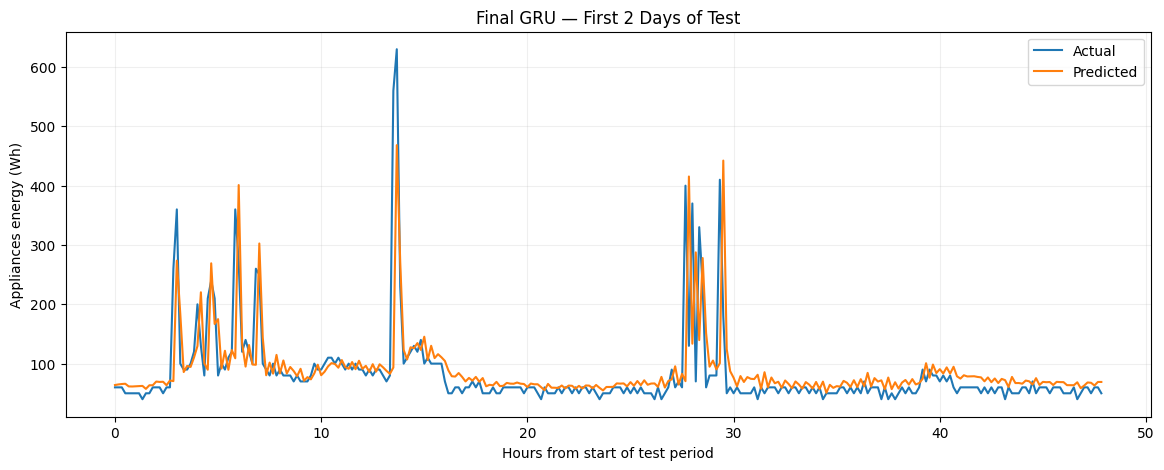

In [23]:
N_DAYS = 2
POINTS_PER_DAY = 144
n_plot = min(N_DAYS * POINTS_PER_DAY, len(test_true))

hours = np.arange(n_plot) / 6

plt.figure(figsize=(14, 5))
plt.plot(hours, test_true[:n_plot], label="Actual")
plt.plot(hours, test_pred[:n_plot], label="Predicted")
plt.xlabel("Hours from start of test period")
plt.ylabel("Appliances energy (Wh)")
plt.title(f"Final {selected_cell} — First {N_DAYS} Days of Test")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

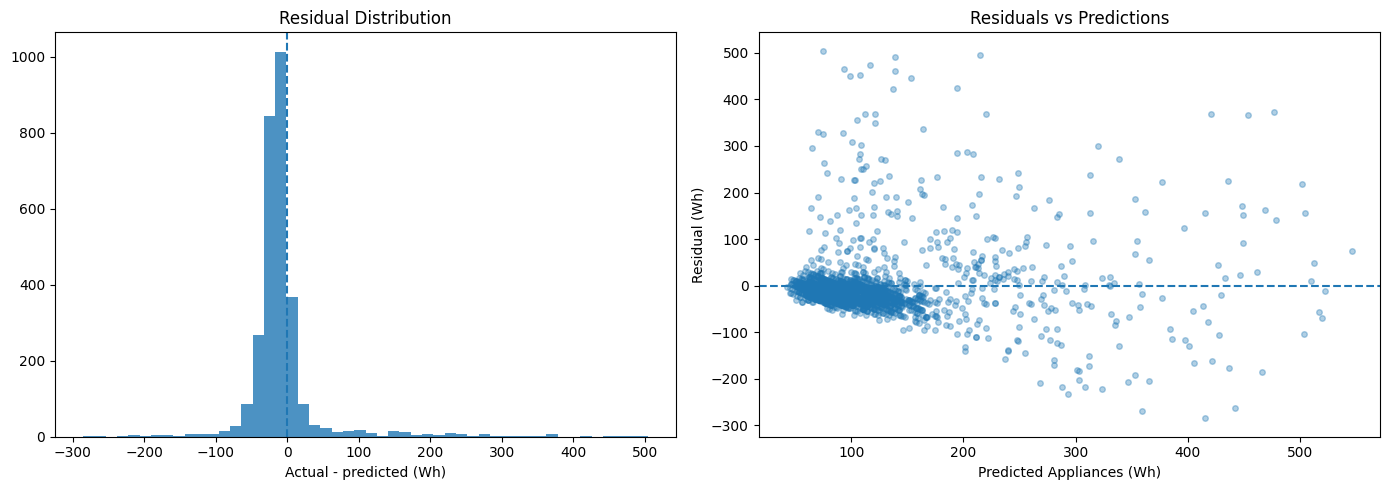

,timestamp,actual_wh,predicted_wh,residual_wh,absolute_error_wh
0,2016-05-27 09:40:00,580.000004,75.219893,504.780111,504.780111
1,2016-05-26 16:30:00,709.999986,215.177471,494.822515,494.822515
2,2016-05-16 17:40:00,630.000012,139.354629,490.645383,490.645383
3,2016-05-21 11:10:00,589.999976,116.607942,473.392033,473.392033
4,2016-05-07 18:10:00,560.000010,93.498862,466.501148,466.501148
5,2016-05-26 11:40:00,599.999997,138.628965,461.371032,461.371032
6,2016-05-13 07:50:00,560.000010,107.904442,452.095569,452.095569
7,2016-05-21 13:10:00,549.999989,99.119431,450.880558,450.880558
8,2016-05-13 11:10:00,599.999997,153.439817,446.560180,446.560180
9,2016-05-13 14:20:00,619.999991,194.671037,425.328954,425.328954


Residual summary
Mean:  -6.57 Wh
Median:-14.10 Wh
Std:   59.58 Wh
Min:   -285.44 Wh
Max:   504.78 Wh


In [24]:
residuals = test_true - test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, alpha=0.8)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual - predicted (Wh)")

axes[1].scatter(test_pred, residuals, alpha=0.35, s=16)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs Predictions")
axes[1].set_xlabel("Predicted Appliances (Wh)")
axes[1].set_ylabel("Residual (Wh)")

plt.tight_layout()
plt.show()

abs_residuals = np.abs(residuals)
largest_indices = np.argsort(abs_residuals)[-15:][::-1]

largest_errors = pd.DataFrame({
    "timestamp": test_dates.iloc[largest_indices].to_numpy(),
    "actual_wh": test_true[largest_indices],
    "predicted_wh": test_pred[largest_indices],
    "residual_wh": residuals[largest_indices],
    "absolute_error_wh": abs_residuals[largest_indices],
})

display(largest_errors.reset_index(drop=True))

print("Residual summary")
print("Mean:  {:.2f} Wh".format(float(np.mean(residuals))))
print("Median:{:.2f} Wh".format(float(np.median(residuals))))
print("Std:   {:.2f} Wh".format(float(np.std(residuals))))
print("Min:   {:.2f} Wh".format(float(np.min(residuals))))
print("Max:   {:.2f} Wh".format(float(np.max(residuals))))

### Residual analysis

The residuals reveal why the final GRU improves RMSE while losing to persistence in MAE.

Using:

\begin{equation}
e_t = y_t - \hat y_t
\end{equation}

negative residuals indicate **overprediction**, while positive residuals indicate **underprediction**.

The mean residual is approximately **-6.6 Wh** and the median is approximately **-14.1 Wh**, showing a systematic tendency to predict above the actual value during ordinary low-consumption periods. These small errors occur frequently and accumulate in MAE.

At the opposite extreme, the positive tail is much longer: the largest residual exceeds **500 Wh**. The largest absolute errors are almost all high-consumption events where the model predicts a much smaller value than the observed spike.

Therefore, the error structure has two regimes:

1. frequent low-consumption observations are often slightly overpredicted;
2. rare high-consumption spikes are often strongly underpredicted.

This is consistent with training a smooth regression model under MSE on a highly skewed target distribution. The model learns the general temporal behavior but tends to compress extreme events toward more common consumption levels.

## 19. Direct multi-horizon forecasting

As an extension, the selected recurrent architecture is trained to predict the next six 10-minute targets simultaneously:

\begin{equation}
[\hat y_{t+1},\hat y_{t+2},\ldots,\hat y_{t+6}]
\end{equation}

This section remains a **validation experiment**; it does not use the one-step test result for model selection.

In [25]:
MULTI_HORIZON = 6

multi_train_dataset, multi_valid_dataset = make_datasets(
    selected_sequence_length,
    horizon=MULTI_HORIZON,
)

multi_train_loader = make_loader(
    multi_train_dataset,
    shuffle=True,
    seed=SEARCH_SEED,
)
multi_valid_loader = make_loader(
    multi_valid_dataset,
    shuffle=False,
)

torch.manual_seed(SEARCH_SEED)

multi_model = TunedRecurrentRegressor(
    cell_type=selected_cell,
    input_size=n_features,
    hidden_size=int(best_config["hidden_size"]),
    num_layers=selected_num_layers,
    dropout=float(best_config["dropout"]),
    output_size=MULTI_HORIZON,
).to(device)

multi_optimizer = torch.optim.AdamW(
    multi_model.parameters(),
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
)

multi_result = fit_model(
    multi_model,
    multi_train_loader,
    multi_valid_loader,
    multi_optimizer,
    nn.MSELoss(),
    device,
    n_epochs=MULTI_EPOCHS,
    max_grad_norm=1.0,
    verbose=False,
)

multi_model.load_state_dict(multi_result.best_state)
print("Best multi-horizon epoch:", multi_result.best_epoch)
print("Best multi-horizon validation MSE (scaled):", multi_result.best_validation_loss)

Best multi-horizon epoch: 5
Best multi-horizon validation MSE (scaled): 0.5247072577476501


,forecast_horizon_min,model_mae,model_rmse,persistence_mae,persistence_rmse
0,10,28.709639,61.810915,26.189509,66.483589
1,20,34.155928,76.551050,37.705584,93.891970
2,30,36.606534,79.648494,43.695431,102.004611
3,40,37.535154,80.788901,46.890017,105.544755
4,50,38.208430,81.627330,49.580372,108.876589
5,60,38.910554,82.043605,51.627749,111.496511


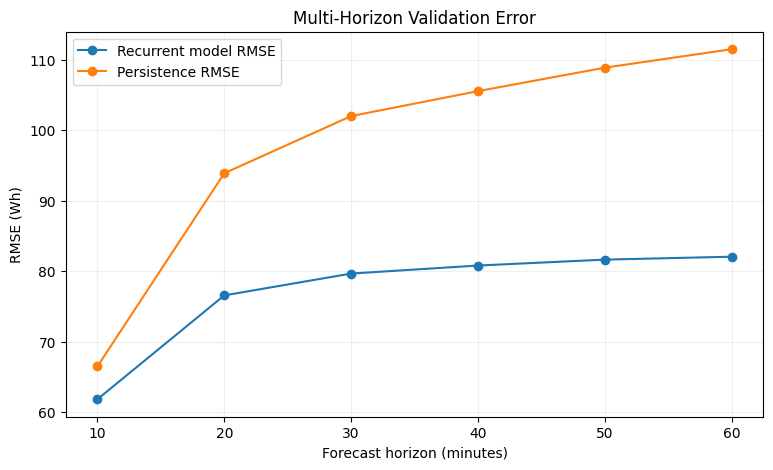

In [26]:
multi_true_scaled, multi_pred_scaled = predict_scaled(
    multi_model,
    multi_valid_loader,
    device,
)

multi_true = inverse_target(multi_true_scaled.numpy())
multi_pred = inverse_target(multi_pred_scaled.numpy())

horizon_rows = []

# Persistence for each direct horizon: repeat the latest known target.
valid_context_scaled = with_history_context(
    train_scaled,
    valid_scaled,
    selected_sequence_length,
)
latest_known_scaled = []

for i in range(len(multi_valid_dataset)):
    X_seq, _ = multi_valid_dataset[i]
    latest_known_scaled.append(
        float(X_seq[-1, target_col_index])
    )

latest_known = inverse_target(
    np.asarray(latest_known_scaled)
)

for h in range(MULTI_HORIZON):
    model_metrics = regression_metrics(
        multi_true[:, h],
        multi_pred[:, h],
    )
    persistence_metrics = regression_metrics(
        multi_true[:, h],
        latest_known,
    )

    horizon_rows.append({
        "forecast_horizon_min": (h + 1) * 10,
        "model_mae": model_metrics["mae"],
        "model_rmse": model_metrics["rmse"],
        "persistence_mae": persistence_metrics["mae"],
        "persistence_rmse": persistence_metrics["rmse"],
    })

multi_horizon_results = pd.DataFrame(horizon_rows)
display(multi_horizon_results)

plt.figure(figsize=(9, 5))
plt.plot(
    multi_horizon_results["forecast_horizon_min"],
    multi_horizon_results["model_rmse"],
    marker="o",
    label="Recurrent model RMSE",
)
plt.plot(
    multi_horizon_results["forecast_horizon_min"],
    multi_horizon_results["persistence_rmse"],
    marker="o",
    label="Persistence RMSE",
)
plt.xlabel("Forecast horizon (minutes)")
plt.ylabel("RMSE (Wh)")
plt.title("Multi-Horizon Validation Error")
plt.xticks(multi_horizon_results["forecast_horizon_min"])
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Multi-horizon analysis

Forecasting becomes more difficult as the prediction horizon grows, but the comparison with persistence becomes more favorable for the recurrent model.

| Horizon | GRU MAE | GRU RMSE | Persistence MAE | Persistence RMSE |
|---|---:|---:|---:|---:|
| +10 min | 28.71 | **61.81** | **26.19** | 66.48 |
| +20 min | **34.16** | **76.55** | 37.71 | 93.89 |
| +30 min | **36.61** | **79.65** | 43.70 | 102.00 |
| +40 min | **37.54** | **80.79** | 46.89 | 105.54 |
| +50 min | **38.21** | **81.63** | 49.58 | 108.88 |
| +60 min | **38.91** | **82.04** | 51.63 | 111.50 |

At +10 minutes, persistence still produces the lower MAE, which is consistent with the one-step test result. From **+20 minutes onward**, however, the GRU outperforms persistence on both MAE and RMSE, and the gap grows with horizon.

This is one of the clearest results of the project. Persistence is difficult to beat when the target is only one timestep away because short-term continuity is strong. As the forecast moves farther into the future, repeatedly assuming that consumption will remain unchanged becomes increasingly unrealistic, while the recurrent representation retains useful information from the recent sequence and environmental variables.

The largest increase in model error occurs between +10 and +20 minutes. Beyond that point, RMSE continues increasing but begins to flatten. This extension is evaluated on validation data only and is treated as a separate forecasting experiment rather than as another opportunity to modify the locked one-step test model.

## 20. Consolidated run summary

In [27]:

print("=" * 80)
print("PORTFOLIO RUN SUMMARY")
print("=" * 80)

print("\nVALIDATION BASELINES")
display(validation_baselines_df)

print("\nRECURRENT ARCHITECTURE COMPARISON")
display(architecture_results)

print("\nCONTEXT-LENGTH COMPARISON")
display(context_results)

print("\nRECURRENT-DEPTH COMPARISON")
display(depth_results)

print("\nHYPERPARAMETER SEARCH")
display(search_results)

print("\nSELECTED VALIDATION CONFIGURATION")
print("Cell:", selected_cell)
print("Sequence length:", selected_sequence_length)
print("Layers:", selected_num_layers)
print("Best config:", best_config)
print("Validation metrics:", validation_metrics)

print("\nTEST BASELINES")
display(test_baselines_df)

print("\nFINAL TEST MODEL")
print(final_test_metrics)

print("\nMULTI-HORIZON VALIDATION")
display(multi_horizon_results)


PORTFOLIO RUN SUMMARY

VALIDATION BASELINES


,model,mae,rmse
0,Persistence (lag 1),26.162162,66.429703
1,Daily seasonal (lag 144),53.320946,115.383760



RECURRENT ARCHITECTURE COMPARISON


,model,sequence_length,parameters,best_epoch,validation_mae,validation_rmse
0,GRU,36,18497,7,25.984000,58.309119
1,RNN,36,6209,9,26.577262,58.620657
2,LSTM,36,24641,7,27.649612,58.954843



CONTEXT-LENGTH COMPARISON


...

,trial,hidden_size,lr,dropout,weight_decay,best_epoch,validation_mae,validation_rmse,validation_mse_scaled
0,7,64,0.0003,0.3,0.0010,15,25.749441,57.911300,0.293731
1,8,32,0.0010,0.3,0.0010,9,24.814059,57.931499,0.293936
2,6,32,0.0010,0.3,0.0001,9,24.819999,57.933216,0.293953
3,5,64,0.0003,0.1,0.0010,15,26.431492,57.950101,0.294125
4,1,64,0.0003,0.2,0.0010,15,26.007396,57.957494,0.294200
5,2,32,0.0003,0.3,0.0010,22,24.861044,57.973790,0.294365
6,3,64,0.0010,0.1,0.0001,10,26.030385,58.010911,0.294742
7,4,64,0.0010,0.3,0.0010,7,25.646006,58.059247,0.295234



SELECTED VALIDATION CONFIGURATION
Cell: GRU
Sequence length: 36
Layers: 2
Best config: {'trial': 7, 'hidden_size': 64, 'lr': 0.0003, 'dropout': 0.3, 'weight_decay': 0.001, 'best_epoch': 15, 'validation_mae': 25.749440976617922, 'validation_rmse': 57.911300200899426, 'validation_mse_scaled': 0.2937309741973877}
Validation metrics: {'mae': 25.749440976617922, 'rmse': 57.911300200899426}

TEST BASELINES


,model,mae,rmse
0,Persistence (lag 1),26.737589,66.836915
1,Daily seasonal (lag 144),52.489024,109.473271



FINAL TEST MODEL
{'mae': 30.7868731812376, 'rmse': 59.94337628392147}

MULTI-HORIZON VALIDATION


,forecast_horizon_min,model_mae,model_rmse,persistence_mae,persistence_rmse
0,10,28.709639,61.810915,26.189509,66.483589
1,20,34.155928,76.551050,37.705584,93.891970
2,30,36.606534,79.648494,43.695431,102.004611
3,40,37.535154,80.788901,46.890017,105.544755
4,50,38.208430,81.627330,49.580372,108.876589
5,60,38.910554,82.043605,51.627749,111.496511


## 21. Results summary

The final pipeline selects a **two-layer GRU** using a 6-hour historical window. The tuned model uses 64 hidden units, dropout of 0.3, AdamW with a learning rate of `3e-4`, and weight decay of `1e-3`.

### Main findings

- The dataset contains a strong short-term persistence signal. A lag-1 forecast is therefore a meaningful baseline rather than a trivial comparison.
- RNN, LSTM, and GRU all reduce validation RMSE relative to persistence. The GRU provides the best recurrent validation result while remaining simpler than the LSTM.
- Increasing the input history from 6 to 144 timesteps does not improve one-step forecasting. A 6-hour context is selected, showing that more sequence history is not automatically beneficial.
- A second GRU layer improves validation performance, although the gain is modest relative to the increase in parameter count.
- Hyperparameter tuning reduces validation RMSE to **57.91 Wh**.
- On the locked chronological test period, the final GRU achieves **30.79 Wh MAE** and **59.94 Wh RMSE**, compared with **26.74 Wh MAE** and **66.84 Wh RMSE** for persistence.
- The recurrent model therefore improves large-error-sensitive RMSE but does not improve the typical absolute one-step error.
- Residual diagnostics show systematic mild overprediction during common low-consumption periods and substantial underprediction during rare high-consumption spikes.
- In direct multi-horizon validation, persistence remains competitive at +10 minutes, but the GRU outperforms it on both MAE and RMSE from +20 through +60 minutes.

### Interpretation

The main value of the recurrent model is not that it uniformly beats a naive forecast. Instead, it changes the error profile.

For extremely short horizons, the most recent observed value already contains a large amount of predictive information, so persistence is difficult to improve in MAE. The GRU becomes more useful when large errors matter more or when the forecasting horizon increases.

The experiment also shows that additional architectural complexity is not automatically beneficial. The LSTM does not improve on the GRU, a 24-hour context does not improve on six hours, and the second recurrent layer provides only a modest gain.

### Limitations

The dataset represents a **single household over approximately 4.5 months**, so the results should not be interpreted as evidence of generalization to other homes, occupants, or seasons.

Model development also relies on a single chronological validation interval rather than rolling-origin evaluation. The rare high-consumption events remain difficult to predict, and the available variables do not explicitly describe appliance usage or occupancy, which likely limits peak forecasting.

Possible extensions include rolling-window backtesting, peak-aware or weighted objectives, probabilistic forecasts, additional occupancy-related signals, and comparison with non-recurrent sequence models. These are left outside the current case study so that the project remains focused on understanding recurrent architectures and temporal validation.